# Dimensionality Reduction on LA Crime Data
## Feature Selection + PCA + Variance Visualization

Using the attached `final_cleaned_crime_data.csv.xls` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

In [2]:
# Load the data
df = pd.read_csv(r"C:\Users\welcome\Downloads\final_cleaned_crime_data.csv")
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (4064, 27)

Columns: ['DR_NO', 'Date Rptd', 'Date', 'Time', 'AREA', 'Area Name', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crime Description', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'LOCATION', 'Latitude', 'Longitude', 'Year', 'Month', 'Day', 'Weekday', 'Hour', 'Time_of_Day']


,DR_NO,Date Rptd,Date,Time,AREA,Area Name,Rpt Dist No,Part 1-2,Crm Cd,Crime Description,...,Crm Cd 1,LOCATION,Latitude,Longitude,Year,Month,Day,Weekday,Hour,Time_of_Day
0,190326475,01-03-2020,01-03-2020,2130,7,wilshire,784,1,510,vehicle - stolen,...,510,1900 S LONGWOOD AV,34.0375,-118.3506,2020,3,1,Sunday,21,Night
1,200106753,09-02-2020,08-02-2020,1800,1,central,182,1,330,burglary from vehicle,...,330,1000 S FLOWER ST,34.0444,-118.2628,2020,2,8,Saturday,18,Evening
2,200320258,11-11-2020,04-11-2020,1700,3,southwest,356,1,480,bike - stolen,...,480,1400 W 37TH ST,34.0210,-118.3002,2020,11,4,Wednesday,17,Evening
3,200907217,10-05-2023,10-03-2020,2037,9,van nuys,964,1,343,shoplifting-grand theft ($950.01 & over),...,343,14000 RIVERSIDE DR,34.1576,-118.4387,2020,3,10,Tuesday,20,Evening
4,200412582,09-09-2020,09-09-2020,630,4,hollenbeck,413,1,510,vehicle - stolen,...,510,200 E AVENUE 28,34.0820,-118.2130,2020,9,9,Wednesday,6,Morning


## 1. Data Exploration & Preprocessing

In [3]:
# Select relevant features for dimensionality reduction
numeric_cols = ['Vict Age', 'Latitude', 'Longitude', 'Hour', 'Month', 'Day', 'AREA', 'Rpt Dist No', 'Premis Cd', 'Crm Cd']
categorical_cols = ['Vict Sex', 'Vict Descent', 'Time_of_Day', 'Weekday', 'Area Name', 'Status Desc']

print('Numeric features:', numeric_cols)
print('Categorical features:', categorical_cols)

Numeric features: ['Vict Age', 'Latitude', 'Longitude', 'Hour', 'Month', 'Day', 'AREA', 'Rpt Dist No', 'Premis Cd', 'Crm Cd']
Categorical features: ['Vict Sex', 'Vict Descent', 'Time_of_Day', 'Weekday', 'Area Name', 'Status Desc']


In [4]:
# Encode categorical variables
df_encoded = df.copy()
le_dict = {}
for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le

# Final feature set
features = numeric_cols + [col for col in categorical_cols if col in df_encoded.columns]
X = df_encoded[features].copy()

# Handle any missing values
X = X.fillna(X.median(numeric_only=True))

print('Final feature matrix shape:', X.shape)

Final feature matrix shape: (4064, 16)


## 2. Feature Selection

In [5]:
# 2.1 Remove low-variance features
selector = VarianceThreshold(threshold=0.1)
X_high_var = selector.fit_transform(X)
high_var_features = [features[i] for i in range(len(features)) if selector.get_support()[i]]

print('Features after low-variance removal:', high_var_features)

Features after low-variance removal: ['Vict Age', 'Hour', 'Month', 'Day', 'AREA', 'Rpt Dist No', 'Premis Cd', 'Crm Cd', 'Vict Sex', 'Vict Descent', 'Time_of_Day', 'Weekday', 'Area Name', 'Status Desc']


In [6]:
# 2.2 SelectKBest (using f_classif with a target, e.g., Crime Description or Crm Cd)
y = df_encoded['Crm Cd']  # using crime code as target for supervised selection

kbest = SelectKBest(score_func=f_classif, k=10)
X_kbest = kbest.fit_transform(X, y)
kbest_features = [features[i] for i in range(len(features)) if kbest.get_support()[i]]

print('Top 10 features by SelectKBest:', kbest_features)

Top 10 features by SelectKBest: ['Vict Age', 'Longitude', 'Hour', 'Premis Cd', 'Crm Cd', 'Vict Sex', 'Vict Descent', 'Time_of_Day', 'Area Name', 'Status Desc']


## 3. Standardization & PCA

In [7]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[high_var_features])

In [8]:
# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

## 4. Visualizing Variance

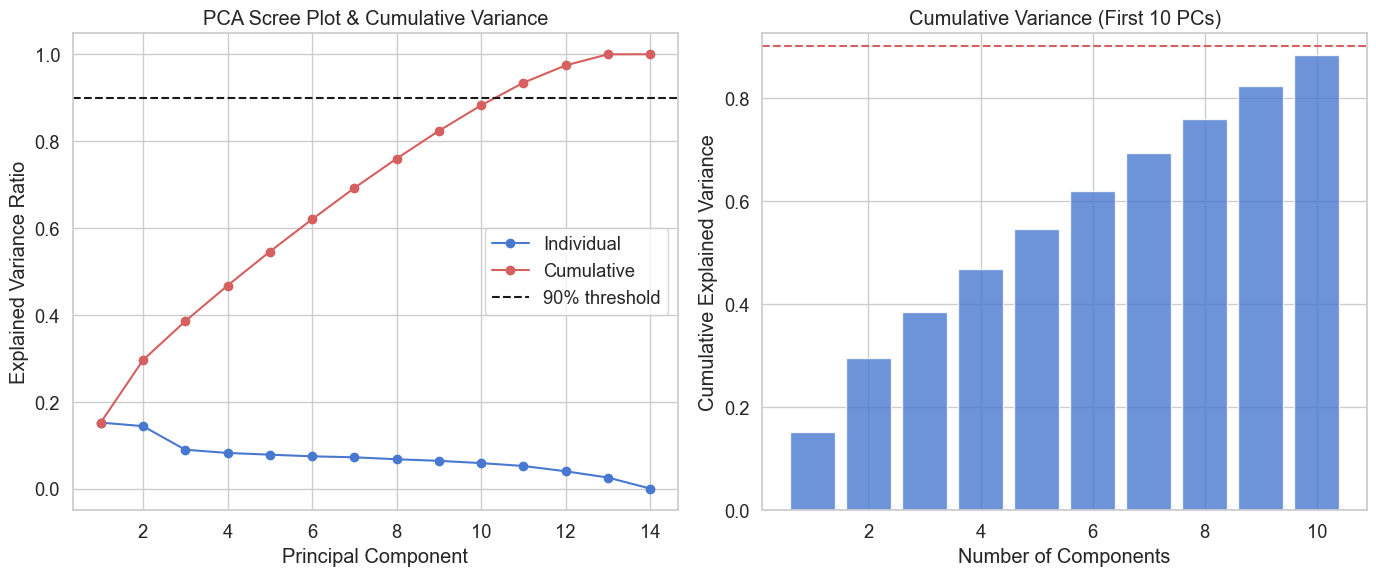

In [9]:
plt.figure(figsize=(14, 6))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'bo-', label='Individual')
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, 'ro-', label='Cumulative')
plt.axhline(y=0.9, color='k', linestyle='--', label='90% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot & Cumulative Variance')
plt.legend()
plt.grid(True)

# Cumulative variance bar
plt.subplot(1, 2, 2)
plt.bar(range(1, 11), cumulative_variance[:10], alpha=0.8)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance (First 10 PCs)')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Find minimum components for 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f'Number of components needed for 90% variance: {n_components_90}')

Number of components needed for 90% variance: 11


## 5. 2D PCA Visualization (colored by Time_of_Day)

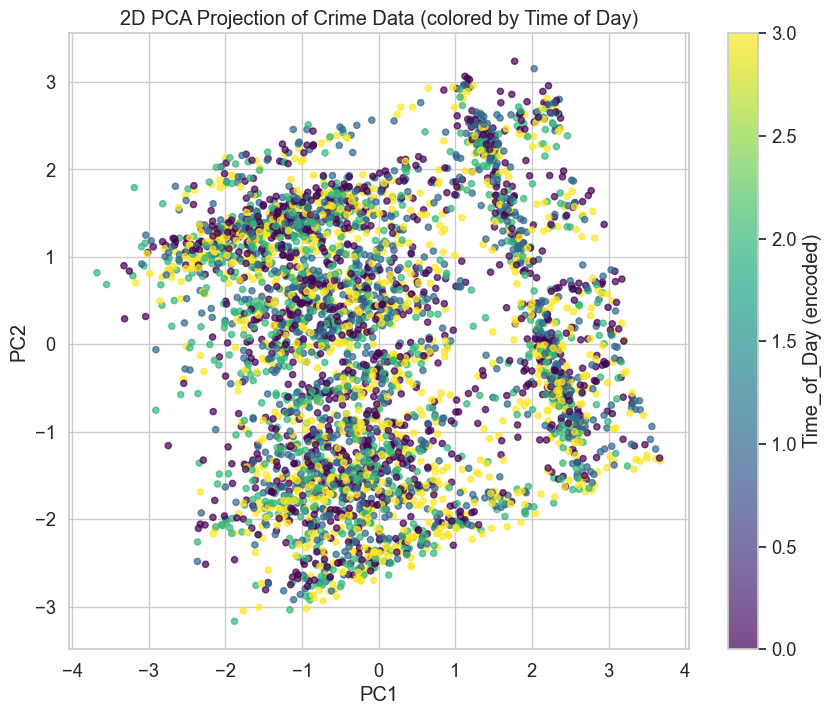

In [11]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=df_encoded['Time_of_Day'], cmap='viridis', alpha=0.7, s=20)
plt.colorbar(scatter, label='Time_of_Day (encoded)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection of Crime Data (colored by Time of Day)')
plt.grid(True)
plt.show()

## Summary & Next Steps
- Low-variance + SelectKBest for feature selection
- PCA shows how many components capture most variance
- 2D projection for visual clustering

You can now experiment with different `k`, targets, or add more features (e.g., one-hot encoding).